# Primary color rating — simulated data

Technical validation of the 8-bot simulation export. This is not a scientific
conclusion about color pleasantness; bots choose ratings at random.


In [1]:
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.dpi"] = 50


def find_attempt_root() -> Path:
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        zip_path = parent / "artifacts" / "simulated_data.zip"
        if zip_path.is_file():
            return parent
    raise FileNotFoundError("Could not find artifacts/simulated_data.zip")


attempt_root = find_attempt_root()
export_zip = attempt_root / "artifacts" / "simulated_data.zip"
print("attempt_root:", attempt_root)
print("export_zip:", export_zip)


attempt_root: /workspace/challenges/primary-color-rating/attempts/2026-08-19-18-54
export_zip: /workspace/challenges/primary-color-rating/attempts/2026-08-19-18-54/artifacts/simulated_data.zip


In [2]:
with ZipFile(export_zip) as zf:
    names = [name for name in zf.namelist() if name.endswith("ColorRatingTrial.csv")]
    anonymous = next(name for name in names if "/anonymous/" in name)
    with zf.open(anonymous) as handle:
        trials = pd.read_csv(BytesIO(handle.read()))

print("rows:", len(trials))
print("participants:", trials["participant_id"].nunique())
print("colors:", sorted(trials["color_name"].unique()))
trials[["participant_id", "color_name", "rating", "answer"]].head()


rows: 24
participants: 8
colors: ['blue', 'green', 'red']


,participant_id,color_name,rating,answer
0,1,blue,4,"{""rating"": 4}"
1,1,green,4,"{""rating"": 4}"
2,1,red,4,"{""rating"": 4}"
3,2,red,7,"{""rating"": 7}"
4,2,blue,7,"{""rating"": 7}"


In [3]:
# One rating per participant per color
counts = (
    trials.groupby(["participant_id", "color_name"])
    .size()
    .reset_index(name="n")
)
assert (counts["n"] == 1).all(), counts
assert set(trials["color_name"]) == {"red", "green", "blue"}
assert trials["rating"].between(1, 7).all()
print("Each participant saved exactly one 1-7 rating per color.")

summary = (
    trials.groupby("color_name")["rating"]
    .agg(["count", "mean", "std", "min", "max"])
    .reindex(["red", "green", "blue"])
)
summary


Each participant saved exactly one 1-7 rating per color.


,count,mean,std,min,max
color_name,,,,,
red,8,4.50,2.000000,1,7
green,8,5.25,1.488048,3,7
blue,8,4.25,2.121320,1,7


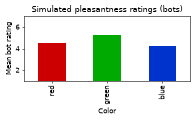

In [4]:
fig, ax = plt.subplots(figsize=(4, 2.5))
summary["mean"].plot(kind="bar", ax=ax, color=["#cc0000", "#00aa00", "#0033cc"])
ax.set_ylim(1, 7)
ax.set_ylabel("Mean bot rating")
ax.set_xlabel("Color")
ax.set_title("Simulated pleasantness ratings (bots)")
plt.tight_layout()
plt.show()
